In [1]:
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [2]:
from utils_pourRL import *



pygame 2.6.1 (SDL 2.28.4, Python 3.13.14)
Hello from the pygame community. https://www.pygame.org/contribute.html
[<utils_pourRL.pique object at 0x000002E67D3178C0>, <utils_pourRL.pique object at 0x000002E67D332710>, <utils_pourRL.carre object at 0x000002E67D317A10>, <utils_pourRL.pique object at 0x000002E67D30FE10>, <utils_pourRL.carre object at 0x000002E67D332990>, <utils_pourRL.pique object at 0x000002E67DB76580>, <utils_pourRL.pique object at 0x000002E675893850>, <utils_pourRL.pique object at 0x000002E67DB0E7B0>, <utils_pourRL.carre object at 0x000002E67DE68180>, <utils_pourRL.pique object at 0x000002E675877930>, <utils_pourRL.pique object at 0x000002E67DBED8B0>, <utils_pourRL.carre object at 0x000002E67DB767A0>, <utils_pourRL.pique object at 0x000002E67CD73290>, <utils_pourRL.plateforme object at 0x000002E67D317B60>, <utils_pourRL.pique object at 0x000002E67DBA0AA0>, <utils_pourRL.pique object at 0x000002E67DE62030>, <utils_pourRL.pique object at 0x000002E66BED9350>, <utils_pourRL

In [3]:
import importlib
import utils_pourRL

importlib.reload(utils_pourRL)

Affichage = utils_pourRL.Affichage


[<utils_pourRL.pique object at 0x000002E67D317770>, <utils_pourRL.pique object at 0x000002E67D332710>, <utils_pourRL.carre object at 0x000002E67D317CB0>, <utils_pourRL.pique object at 0x000002E67D30DE00>, <utils_pourRL.carre object at 0x000002E67D332C10>, <utils_pourRL.pique object at 0x000002E67DB76E00>, <utils_pourRL.pique object at 0x000002E67DBF5050>, <utils_pourRL.pique object at 0x000002E67DB0EA80>, <utils_pourRL.carre object at 0x000002E67DE68180>, <utils_pourRL.pique object at 0x000002E67D6DBE70>, <utils_pourRL.pique object at 0x000002E67DBEE820>, <utils_pourRL.carre object at 0x000002E67DB77020>, <utils_pourRL.pique object at 0x000002E67CD73350>, <utils_pourRL.plateforme object at 0x000002E67D317E00>, <utils_pourRL.pique object at 0x000002E67DBA0D60>, <utils_pourRL.pique object at 0x000002E67DE63570>, <utils_pourRL.pique object at 0x000002E67DBE4ED0>, <utils_pourRL.pique object at 0x000002E67DB88C20>, <utils_pourRL.plateforme object at 0x000002E67D332FD0>, <utils_pourRL.pique 

In [4]:
class DQN(nn.Module):

    def __init__(self, n_observation = 8):
        super().__init__()
        self.layer1 = nn.Linear(n_observation, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [5]:
policy_net = DQN()
target_net = DQN()

In [6]:
def choisir_action(state, epsilon):
    if random.random() < epsilon:
        return random.choice([0,1])
    state = torch.tensor(state, dtype = torch.float32)
    q_values = policy_net(state)
    return torch.argmax(q_values).item()

epsilon = 0.4


In [10]:
import time
import pygame
import utils_pourRL

def jouer(jeu):
    state = jeu.reset()
    affichage = utils_pourRL.Affichage(jeu)
    running = True

    policy_net.eval()

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not running:
            break

        state_tensor = torch.tensor(state, dtype=torch.float32)

        with torch.no_grad():
            q_values = policy_net(state_tensor)
            action = torch.argmax(q_values).item()

        next_state, reward, done = jeu.step(action)

        affichage.dessiner()
        pygame.display.flip()

        if done:
            print("Fin de la partie. Score :", jeu.score)
            running = False
        else:
            state = next_state

        time.sleep(1 / 60)

    pygame.quit()

jouer(jeu)

 

Fin de la partie. Score : 469


In [9]:
nb_episodes = 10000
criterion = nn.SmoothL1Loss()
memory = deque(maxlen=10000)
optimizer = optim.Adam(policy_net.parameters(), lr = 0.001)
step_count = 0
score = []

for episode in range(nb_episodes):

    state = jeu.reset()
    done = False
    
    
    while not done:
        step_count += 1
        action = choisir_action(state, epsilon)

        next_state, reward, done = jeu.step(action)

        memory.append(
            (state, action, reward, next_state, done)
        )

        if len(memory) >= 64:
            batch = random.sample(memory, 64)
            states, actions, rewards, next_states, dones = zip(*batch)
            states = torch.tensor(states, dtype=torch.float32)
            actions = torch.tensor(actions, dtype=torch.long)
            rewards = torch.tensor(rewards, dtype=torch.float32)
            next_states = torch.tensor(next_states, dtype=torch.float32)
            dones = torch.tensor(dones, dtype=torch.float32)

            output = policy_net(states)
            q_sa = output.gather(1, actions.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                next_q_values = target_net(next_states)
                max_next_q = next_q_values.max(dim=1).values
                cible = rewards + 0.99 * (1 - dones) * max_next_q
            loss = criterion(cible, q_sa)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if step_count % 2000 == 0:
            target_net.load_state_dict(policy_net.state_dict())

        state = next_state

    score.append(jeu.score)
    print(loss)



tensor(0.0319, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0335, grad_fn=<SmoothL1LossBackward0>)
tensor(2.4345, grad_fn=<SmoothL1LossBackward0>)
tensor(2.0827, grad_fn=<SmoothL1LossBackward0>)
tensor(0.4777, grad_fn=<SmoothL1LossBackward0>)
tensor(3.5946, grad_fn=<SmoothL1LossBackward0>)
tensor(0.1675, grad_fn=<SmoothL1LossBackward0>)
tensor(4.2897, grad_fn=<SmoothL1LossBackward0>)
tensor(1.8506, grad_fn=<SmoothL1LossBackward0>)
tensor(1.8411, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0524, grad_fn=<SmoothL1LossBackward0>)
tensor(1.7884, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0177, grad_fn=<SmoothL1LossBackward0>)
tensor(1.7907, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0445, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0239, grad_fn=<SmoothL1LossBackward0>)
tensor(2.1253, grad_fn=<SmoothL1LossBackward0>)
tensor(2.1756, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0546, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0262, grad_fn=<SmoothL1LossBackward0>)
tensor(1.7999, grad_fn=<SmoothL1LossBack

KeyboardInterrupt: 

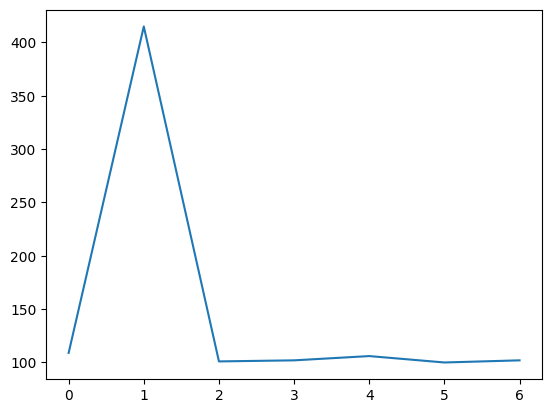

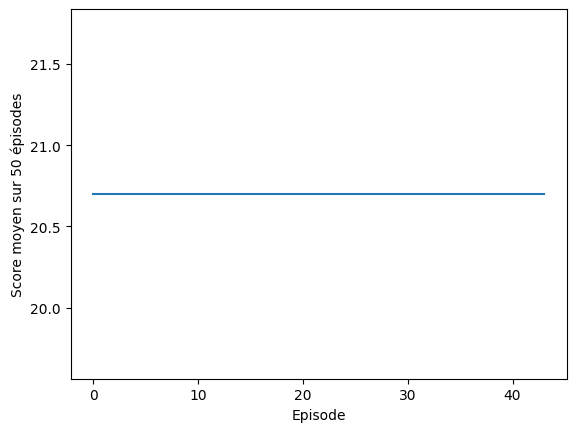

In [46]:
import numpy as np

plt.plot(score)
plt.show()

window = 50

moyennes = np.convolve(
    score,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(moyennes)
plt.xlabel("Episode")
plt.ylabel("Score moyen sur 50 épisodes")
plt.show()